# 03 â€” Model Training & Backtesting

**Goal:** Train position-specific Ridge regression models and validate them.

Steps:
1. Train FantasyProjectionModel on YoY pairs (2020â†’2021 through 2023â†’2024)
2. Review CV RÂ² and alpha grid search results per position
3. Plot feature importances
4. Backtest: hold out 2024, predict it, compare to actuals
5. Fit and plot aging curves
6. Residual analysis: who did the model miss on and why?

In [1]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from config import TRAINING_SEASONS, POSITIONS, POSITION_FEATURES
from features.assembler import assemble_feature_matrix, build_yoy_pairs
from models.projection import FantasyProjectionModel
from models.age_curves import plot_age_curves, fit_age_curves

print('Imports OK')

Imports OK


## 1. Load Feature Matrix

In [2]:
feature_matrix = assemble_feature_matrix(TRAINING_SEASONS)
yoy = build_yoy_pairs(feature_matrix)
print(f'Feature matrix: {feature_matrix.shape}')
print(f'YoY pairs: {len(yoy)}')

Loading feature matrix from cache: feature_matrix_2020_2021_2022_2023_2024.parquet
Feature matrix: (1452, 127)
YoY pairs: 814


## 2. Train Models

In [3]:
model = FantasyProjectionModel(age_adjust=True)
model.train(yoy)

Fitting age curves...
  QB: n=128, features=13, alpha=10.0, CV MAE=3.01
  RB: n=232, features=22, alpha=10.0, CV MAE=3.15
  WR: n=329, features=23, alpha=100.0, CV MAE=2.81
  TE: n=125, features=16, alpha=10.0, CV MAE=2.02


In [4]:
# Best alpha per position
print('Best regularization alpha per position:')
for pos, alpha in model._best_alphas.items():
    print(f'  {pos}: alpha={alpha}')

Best regularization alpha per position:
  QB: alpha=10.0
  RB: alpha=10.0
  WR: alpha=100.0
  TE: alpha=10.0


## 3. Feature Importances

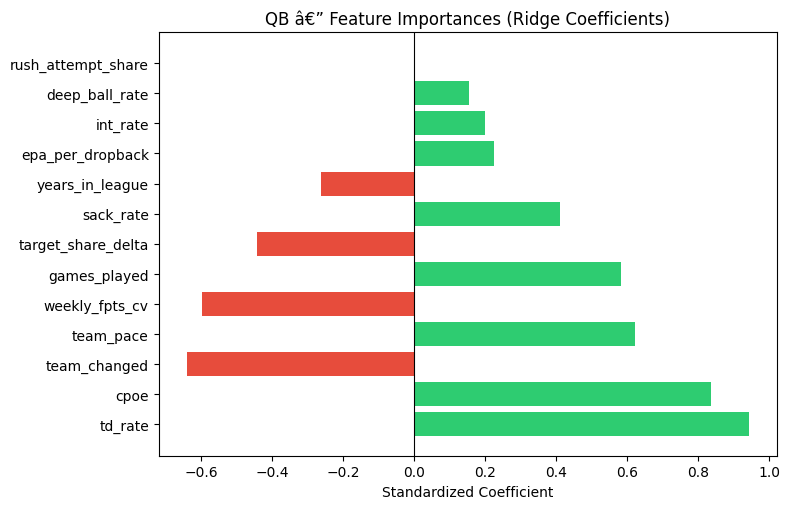


QB top factors:
       feature  coefficient  abs_coefficient
       td_rate     0.942419         0.942419
          cpoe     0.837381         0.837381
  team_changed    -0.640786         0.640786
     team_pace     0.621466         0.621466
weekly_fpts_cv    -0.596817         0.596817


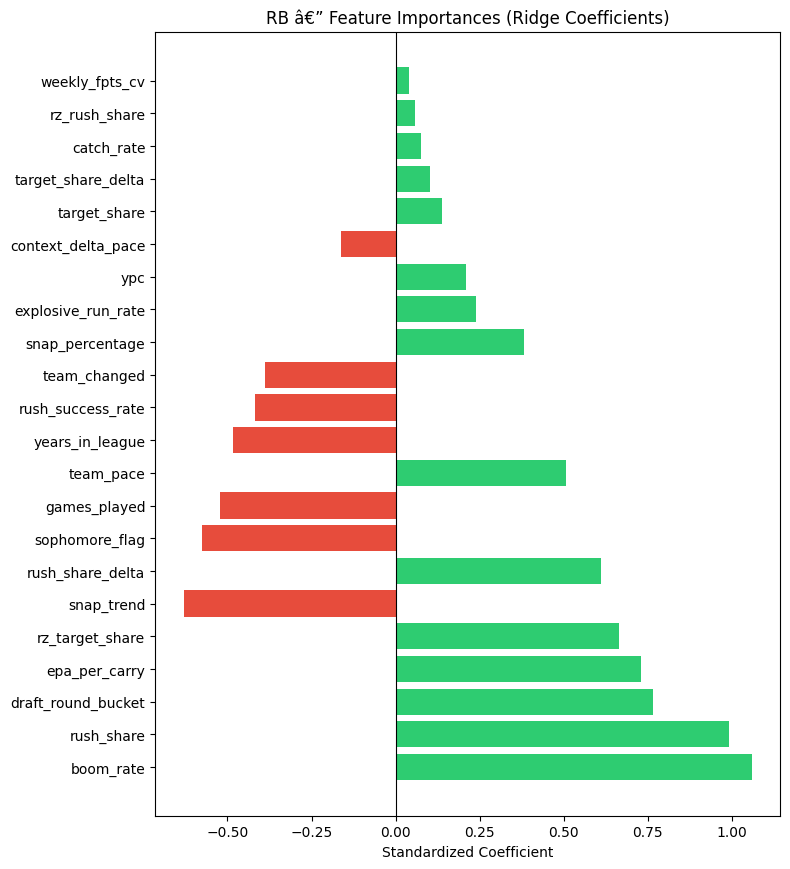


RB top factors:
           feature  coefficient  abs_coefficient
         boom_rate     1.058876         1.058876
        rush_share     0.992184         0.992184
draft_round_bucket     0.767073         0.767073
     epa_per_carry     0.730129         0.730129
   rz_target_share     0.664306         0.664306


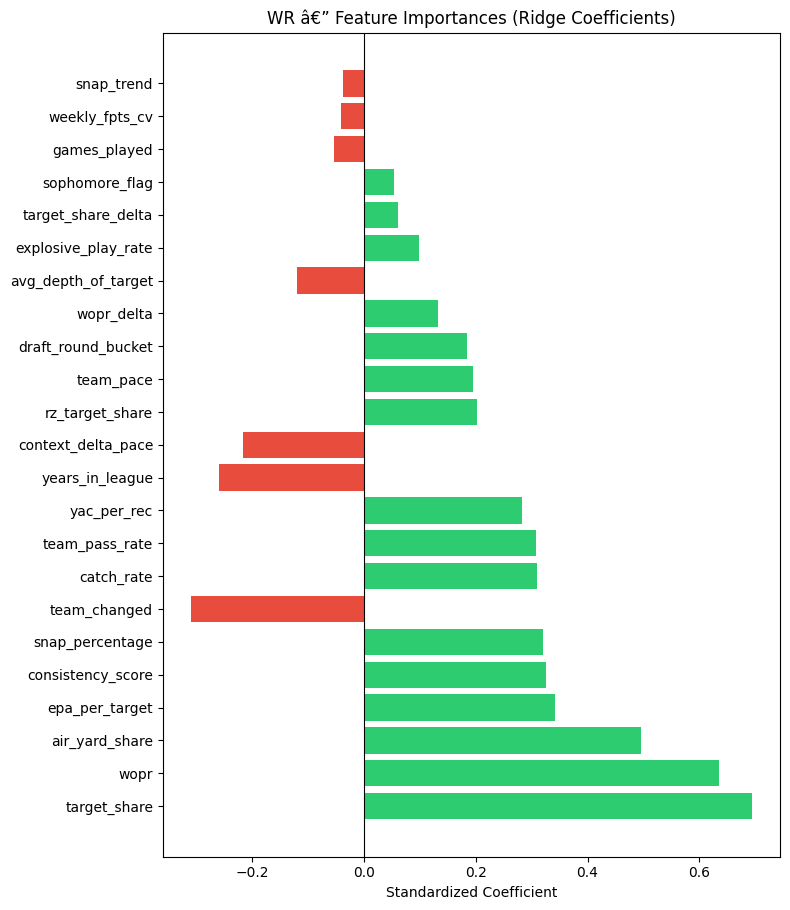


WR top factors:
          feature  coefficient  abs_coefficient
     target_share     0.694194         0.694194
             wopr     0.635313         0.635313
   air_yard_share     0.496228         0.496228
   epa_per_target     0.340979         0.340979
consistency_score     0.325257         0.325257


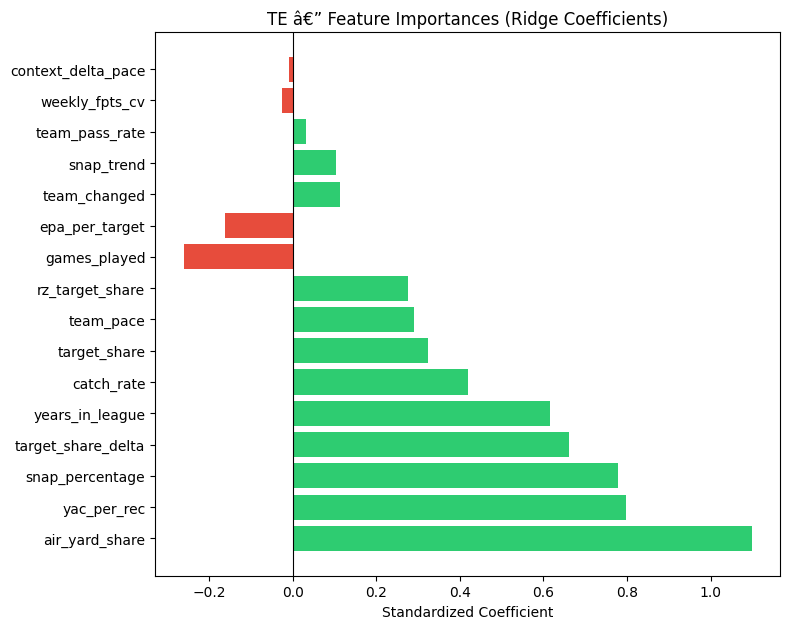


TE top factors:
           feature  coefficient  abs_coefficient
    air_yard_share     1.098143         1.098143
       yac_per_rec     0.798481         0.798481
   snap_percentage     0.778974         0.778974
target_share_delta     0.661344         0.661344
   years_in_league     0.616384         0.616384


In [5]:
for pos in POSITIONS:
    if pos not in model._models:
        continue
    try:
        importance = model.feature_importance(pos)
        
        fig, ax = plt.subplots(figsize=(8, max(4, len(importance) * 0.4)))
        colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in importance['coefficient']]
        ax.barh(importance['feature'], importance['coefficient'], color=colors)
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f'{pos} â€” Feature Importances (Ridge Coefficients)', fontsize=12)
        ax.set_xlabel('Standardized Coefficient')
        plt.tight_layout()
        plt.show()
        
        print(f'\n{pos} top factors:')
        print(importance.head(5).to_string(index=False))
    except Exception as e:
        print(f'{pos}: {e}')

## 4. Backtest 2024

In [6]:
backtest_results = model.backtest(yoy, test_season=2023)  # Use 2023 as test (need 2024 data for N+1 target)
print('Backtest results:')
for pos, stats in backtest_results.items():
    print(f'  {pos}: MAE={stats["mae"]:.2f}, RÂ²={stats["r2"]:.3f}, RankCorr={stats["rank_corr"]:.3f}, n={stats["n"]}')

  QB: n=97, features=13, alpha=100.0, CV MAE=3.02
  RB: n=173, features=22, alpha=100.0, CV MAE=3.14
  WR: n=245, features=23, alpha=100.0, CV MAE=2.75
  TE: n=92, features=16, alpha=10.0, CV MAE=2.21
Backtest results:
  QB: MAE=2.98, RÂ²=0.329, RankCorr=0.714, n=31
  RB: MAE=3.52, RÂ²=0.387, RankCorr=0.678, n=59
  WR: MAE=2.77, RÂ²=0.392, RankCorr=0.645, n=84
  TE: MAE=1.69, RÂ²=0.500, RankCorr=0.720, n=33
  overall: MAE=2.85, RÂ²=0.471, RankCorr=0.699, n=207


  QB: n=97, features=13, alpha=100.0, CV MAE=3.02
  RB: n=173, features=22, alpha=100.0, CV MAE=3.14
  WR: n=245, features=23, alpha=100.0, CV MAE=2.75
  TE: n=92, features=16, alpha=10.0, CV MAE=2.21


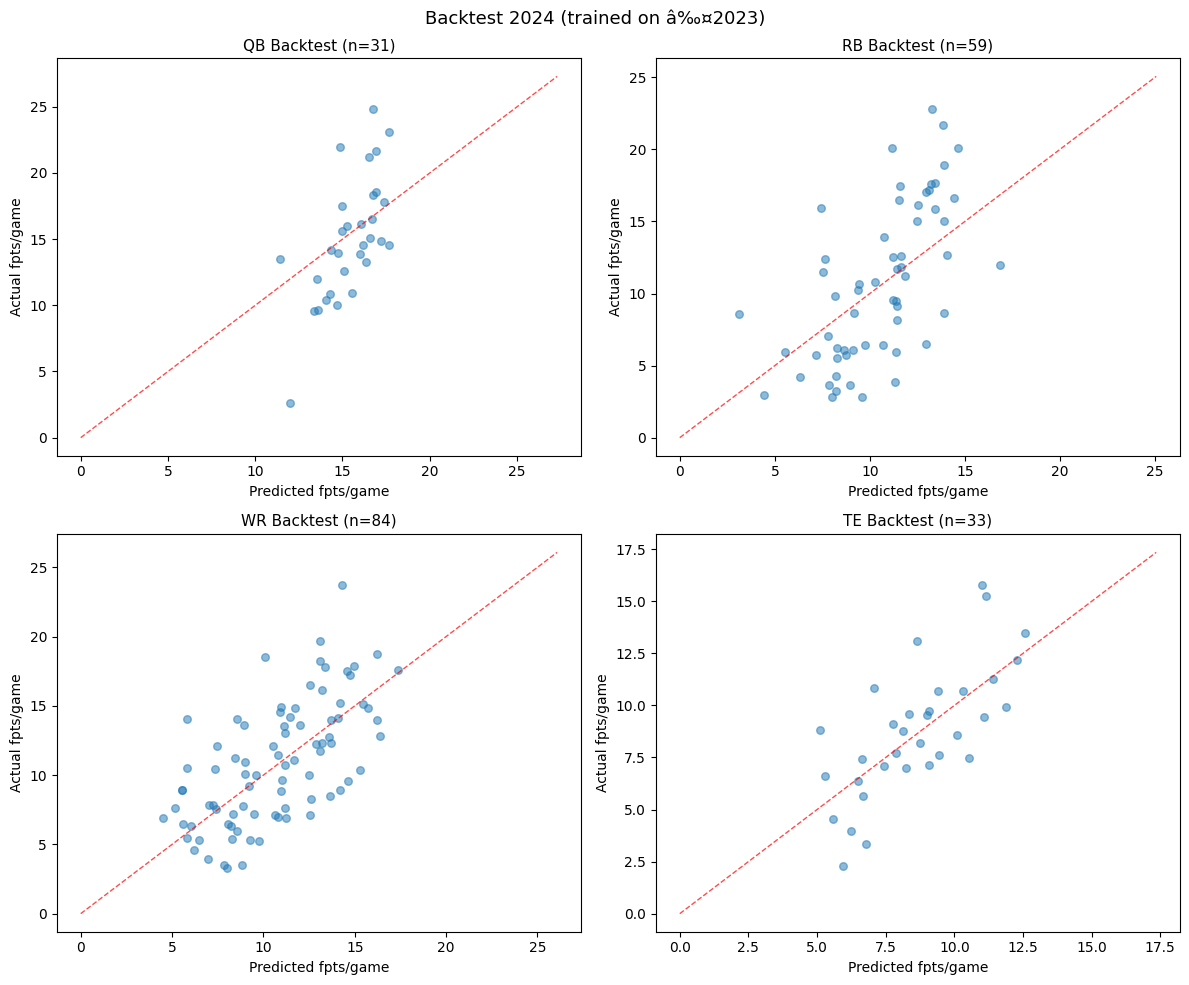

In [7]:
# Scatter: predicted vs. actual for backtest season
test_season = 2023
train_df = yoy[yoy['season'] < test_season]
test_df = yoy[yoy['season'] == test_season]

bt_model = FantasyProjectionModel(age_adjust=False)
bt_model.train(train_df, fit_age=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, pos in zip(axes.flat, POSITIONS):
    pos_test = test_df[test_df['position'] == pos]
    if pos_test.empty or pos not in bt_model._models:
        ax.text(0.5, 0.5, f'{pos}: no data', ha='center', va='center', transform=ax.transAxes)
        continue
    
    features = [f for f in POSITION_FEATURES[pos] if f in pos_test.columns]
    if not features:
        continue
    
    X = pos_test[features].values
    y_actual = pos_test['next_fpts'].values
    y_pred = bt_model._models[pos].predict(X)
    
    valid = ~np.isnan(y_actual)
    ax.scatter(y_pred[valid], y_actual[valid], alpha=0.5, s=30)
    
    # Perfect prediction line
    lim = max(y_actual[valid].max(), y_pred[valid].max()) * 1.1
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1, alpha=0.7)
    
    ax.set_xlabel('Predicted fpts/game')
    ax.set_ylabel('Actual fpts/game')
    ax.set_title(f'{pos} Backtest (n={valid.sum()})', fontsize=11)

plt.suptitle(f'Backtest {test_season+1} (trained on â‰¤{test_season})', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Aging Curves

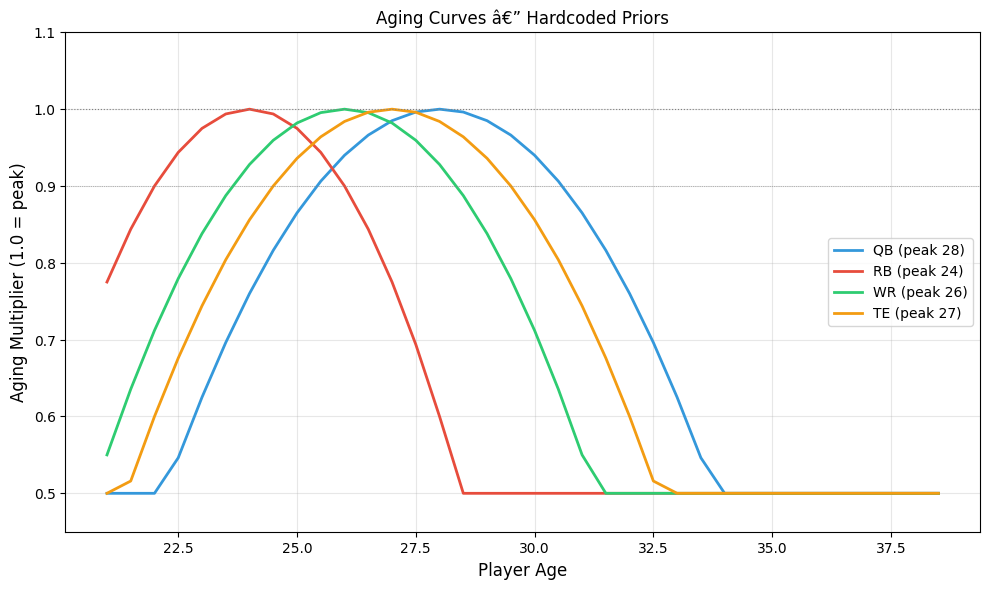

  QB: fitted peak=25.9, decay=0.1000 (prior: peak=28, decay=0.015)
  RB: fitted peak=27.0, decay=0.1000 (prior: peak=24, decay=0.025)
  WR: fitted peak=29.2, decay=0.1000 (prior: peak=26, decay=0.018)
  TE: fitted peak=29.2, decay=0.1000 (prior: peak=27, decay=0.016)


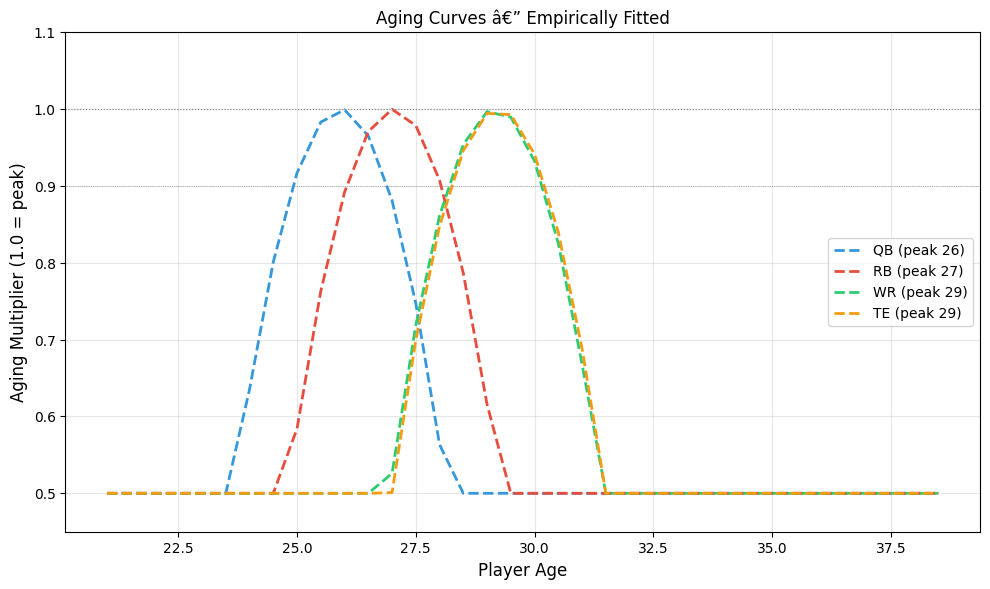

In [8]:
# Hardcoded priors
fig = plot_age_curves()
plt.title('Aging Curves â€” Hardcoded Priors')
plt.show()

# Try fitting empirical curves
try:
    fitted = fit_age_curves(feature_matrix)
    fig = plot_age_curves(fitted)
    plt.title('Aging Curves â€” Empirically Fitted')
    plt.show()
except Exception as e:
    print(f'Empirical fitting failed: {e}')

## 6. Residual Analysis

In [9]:
# Who did the model miss most on? Helps identify model blind spots.
for pos in POSITIONS:
    pos_test = test_df[test_df['position'] == pos].copy()
    if pos_test.empty or pos not in bt_model._models:
        continue
    
    features = [f for f in POSITION_FEATURES[pos] if f in pos_test.columns]
    if not features:
        continue
    
    X = pos_test[features].values
    pos_test['predicted'] = bt_model._models[pos].predict(X)
    pos_test['residual'] = pos_test['next_fpts'] - pos_test['predicted']
    pos_test['abs_residual'] = pos_test['residual'].abs()
    
    top_misses = pos_test.nlargest(5, 'abs_residual')[['player_name', 'team', 'age', 'predicted', 'next_fpts', 'residual']]
    top_misses = top_misses.round(2)
    print(f'\n{pos} â€” Biggest misses:')
    print(top_misses.to_string(index=False))


QB â€” Biggest misses:
             player_name team  age  predicted  next_fpts  residual
Dorian Thompson-Robinson  CLE 23.0      12.02       2.63     -9.39
           Lamar Jackson  BAL 26.0      16.75      24.82      8.07
              Joe Burrow  CIN 26.0      14.84      21.93      7.09
              Josh Allen  BUF 27.0      17.66      23.07      5.41
             Jalen Hurts  PHI 25.0      16.92      21.66      4.75

RB â€” Biggest misses:
    player_name team  age  predicted  next_fpts  residual
 Saquon Barkley  NYG 26.0      13.29      22.79      9.49
  Derrick Henry  TEN 29.0      11.17      20.07      8.90
    Chase Brown  CIN 23.0       7.43      15.94      8.50
   Jahmyr Gibbs  DET 21.0      13.85      21.69      7.84
Ezekiel Elliott   NE 28.0      11.32       3.83     -7.48

WR â€” Biggest misses:
     player_name team  age  predicted  next_fpts  residual
   Ja'Marr Chase  CIN 23.0      14.28      23.71      9.43
     Tee Higgins  CIN 24.0      10.11      18.51      8.40
 

## 7. Two-Stage Volume × Efficiency Model

Decomposed model with separate regularization for volume (persistent) and efficiency (noisy) signals, plus TD rate mean reversion.

> **Note:** First run after adding v2 features requires `force_recompute=True` in the assemble_feature_matrix() call above.

In [10]:
from models.two_stage import TwoStageProjectionModel, ALL_RATE_TARGET_COLS

# Build YoY pairs with extra rate-stat targets needed by two-stage model
rate_cols = [c for c in ALL_RATE_TARGET_COLS if c in feature_matrix.columns]
yoy_two_stage = build_yoy_pairs(feature_matrix, extra_target_cols=rate_cols)
print(f'YoY pairs with rate targets: {len(yoy_two_stage)}')
print(f'Rate target columns available: {[c for c in ["next_"+r for r in rate_cols] if c in yoy_two_stage.columns]}')


YoY pairs with rate targets: 814
Rate target columns available: ['next_targets_per_game', 'next_carries_per_game', 'next_dropbacks_per_game', 'next_yards_per_target', 'next_rec_td_rate', 'next_rush_td_rate', 'next_pass_yards_per_attempt', 'next_pass_td_rate', 'next_catch_rate']


In [11]:
ts_model = TwoStageProjectionModel(age_adjust=True)
ts_model.train(yoy_two_stage)


Fitting age curves...
  Training QB (n=128)...
    vol/dropbacks_per_game: alpha=10.0
    eff/pass_yards_per_attempt: alpha=10.0
    eff/pass_td_rate: alpha=10.0
  Training RB (n=232)...
    vol/carries_per_game: alpha=10.0
    vol/targets_per_game: alpha=10.0
    eff/yards_per_target: alpha=1000.0
    eff/rec_td_rate: alpha=10.0
    eff/rush_td_rate: alpha=1000.0
  Training WR (n=329)...
    vol/targets_per_game: alpha=1.0
    eff/yards_per_target: alpha=10.0
    eff/rec_td_rate: alpha=10.0
  Training TE (n=125)...
    vol/targets_per_game: alpha=10.0
    eff/yards_per_target: alpha=100.0
    eff/rec_td_rate: alpha=1000.0


In [13]:
# --- Backtest comparison: single-stage vs two-stage ---
print('Single-stage model (baseline):')
for pos, stats in backtest_results.items():
    print(f'  {pos}: MAE={stats["mae"]:.2f}, R²={stats["r2"]:.3f}, RankCorr={stats["rank_corr"]:.3f}, n={stats["n"]}')

print('Two-stage model:')
ts_backtest = ts_model.backtest(yoy_two_stage, test_season=2023)
for pos, stats in ts_backtest.items():
    print(f'  {pos}: MAE={stats["mae"]:.2f}, R²={stats["r2"]:.3f}, RankCorr={stats["rank_corr"]:.3f}, n={stats["n"]}')


Single-stage model (baseline):
  QB: MAE=2.98, R²=0.329, RankCorr=0.714, n=31
  RB: MAE=3.52, R²=0.387, RankCorr=0.678, n=59
  WR: MAE=2.77, R²=0.392, RankCorr=0.645, n=84
  TE: MAE=1.69, R²=0.500, RankCorr=0.720, n=33
  overall: MAE=2.85, R²=0.471, RankCorr=0.699, n=207
Two-stage model:
  Training QB (n=97)...
    vol/dropbacks_per_game: alpha=10.0
    eff/pass_yards_per_attempt: alpha=10.0
    eff/pass_td_rate: alpha=10.0
  Training RB (n=173)...
    vol/carries_per_game: alpha=10.0
    vol/targets_per_game: alpha=10.0
    eff/yards_per_target: alpha=1000.0
    eff/rec_td_rate: alpha=100.0
    eff/rush_td_rate: alpha=1000.0
  Training WR (n=245)...
    vol/targets_per_game: alpha=10.0
    eff/yards_per_target: alpha=10.0
    eff/rec_td_rate: alpha=10.0
  Training TE (n=92)...
    vol/targets_per_game: alpha=10.0
    eff/yards_per_target: alpha=1000.0
    eff/rec_td_rate: alpha=100.0
  QB: MAE=3.04, R²=0.306, RankCorr=0.642, n=31
  RB: MAE=4.14, R²=0.206, RankCorr=0.643, n=59
  WR: MA

In [14]:
# --- Intermediate diagnostics: volume and efficiency R² ---
print('Two-stage intermediate diagnostics (volume/efficiency R²):')
for pos in ['QB', 'RB', 'WR', 'TE']:
    if pos not in ts_backtest:
        continue
    stats = ts_backtest[pos]
    vol_keys = {k: v for k, v in stats.items() if k.startswith('volume_r2_')}
    eff_keys = {k: v for k, v in stats.items() if k.startswith('efficiency_r2_')}
    print(f'  {pos}:')
    for k, v in vol_keys.items():
        print(f'    {k}: {v:.3f}')
    for k, v in eff_keys.items():
        print(f'    {k}: {v:.3f}')


Two-stage intermediate diagnostics (volume/efficiency R²):
  QB:
    volume_r2_dropbacks_per_game: -0.118
    efficiency_r2_pass_yards_per_attempt: 0.291
    efficiency_r2_pass_td_rate: 0.192
  RB:
    volume_r2_carries_per_game: 0.403
    volume_r2_targets_per_game: 0.395
    efficiency_r2_yards_per_target: -0.026
    efficiency_r2_rec_td_rate: -0.008
    efficiency_r2_rush_td_rate: -0.001
  WR:
    volume_r2_targets_per_game: 0.403
    efficiency_r2_yards_per_target: 0.055
    efficiency_r2_rec_td_rate: -0.008
  TE:
    volume_r2_targets_per_game: 0.596
    efficiency_r2_yards_per_target: -0.034
    efficiency_r2_rec_td_rate: -0.010


In [15]:
# --- Side-by-side comparison table ---
import pandas as pd
rows = []
for pos in ['QB', 'RB', 'WR', 'TE', 'overall']:
    ss = backtest_results.get(pos, {})
    ts = ts_backtest.get(pos, {})
    rows.append({
        'position': pos,
        'ss_mae': ss.get('mae', float('nan')),
        'ts_mae': ts.get('mae', float('nan')),
        'ss_r2': ss.get('r2', float('nan')),
        'ts_r2': ts.get('r2', float('nan')),
        'ss_rank_corr': ss.get('rank_corr', float('nan')),
        'ts_rank_corr': ts.get('rank_corr', float('nan')),
    })
comp_df = pd.DataFrame(rows)
comp_df.columns = ['Pos', 'SS MAE', 'TS MAE', 'SS R²', 'TS R²', 'SS RankCorr', 'TS RankCorr']
comp_df['MAE Δ'] = (comp_df['TS MAE'] - comp_df['SS MAE']).round(3)
comp_df['R² Δ'] = (comp_df['TS R²'] - comp_df['SS R²']).round(3)
print(comp_df.to_string(index=False))


    Pos  SS MAE  TS MAE  SS R²  TS R²  SS RankCorr  TS RankCorr  MAE Δ   R² Δ
     QB   2.980   3.043  0.329  0.306        0.714        0.642  0.063 -0.023
     RB   3.521   4.137  0.387  0.206        0.678        0.643  0.616 -0.181
     WR   2.775   2.807  0.392  0.367        0.645        0.631  0.032 -0.025
     TE   1.690   1.886  0.500  0.406        0.720        0.702  0.196 -0.094
overall   2.845   3.074  0.471  0.391        0.699        0.647  0.229 -0.080


In [17]:
# --- Feature importance for two-stage model ---
for pos in ['QB', 'RB', 'WR', 'TE']:
    try:
        fi = ts_model.feature_importance(pos)
        if fi.empty:
            print(f'{pos}: no fitted models')
            continue
        print(f'{pos} — Two-stage feature importances (top 15 by |coef|):')
        print(fi.head(15)[['model_stage', 'feature', 'coefficient']].to_string(index=False))
    except Exception as e:
        print(f'{pos}: {e}')


QB — Two-stage feature importances (top 15 by |coef|):
                      model_stage            feature  coefficient
        volume/dropbacks_per_game   epa_per_dropback     1.174272
        volume/dropbacks_per_game target_share_delta    -1.129668
        volume/dropbacks_per_game               cpoe     0.482045
efficiency/pass_yards_per_attempt   epa_per_dropback     0.365048
        volume/dropbacks_per_game          team_pace     0.316628
        volume/dropbacks_per_game context_delta_pace     0.254826
        volume/dropbacks_per_game       team_changed     0.175578
        volume/dropbacks_per_game       games_played     0.170608
efficiency/pass_yards_per_attempt               cpoe     0.108110
efficiency/pass_yards_per_attempt          sack_rate     0.085350
efficiency/pass_yards_per_attempt     deep_ball_rate     0.069219
efficiency/pass_yards_per_attempt           int_rate     0.012269
          efficiency/pass_td_rate   epa_per_dropback     0.004222
          efficiency/

## 8. v3 Rolling Backtest — Walk-Forward Validation

Multi-season walk-forward validation: train on all seasons before each test season, evaluate on the held-out season. Tests seasons [2021, 2022, 2023] each have 4+ prior training years with the expanded 2017–2024 window.

> **Note:** First run requires `force_recompute=True` in `assemble_feature_matrix()` above — the v3 cache key (`_v3` suffix) is different from v2.

Models compared:
- **single_stage**: FantasyProjectionModel (Ridge, holistic)
- **two_stage_regressed**: TwoStageProjectionModel with regressed efficiency (fixed v3)
- **hybrid_55**: HybridProjectionModel, 55% single-stage / 45% two-stage

In [ ]:
from models.backtest import rolling_backtest, compare_models
from models.two_stage import TwoStageProjectionModel, ALL_RATE_TARGET_COLS
from models.hybrid import HybridProjectionModel
from models.projection import FantasyProjectionModel

# Build YoY pairs with rate targets for two-stage and hybrid models
rate_cols = [c for c in ALL_RATE_TARGET_COLS if c in feature_matrix.columns]
yoy_v3 = build_yoy_pairs(feature_matrix, extra_target_cols=rate_cols)
print(f'YoY pairs (v3): {len(yoy_v3)}')
print(f'Seasons covered: {sorted(yoy_v3["season"].unique().tolist())}')
print(f'Rate target columns: {[c for c in ["next_"+r for r in rate_cols] if c in yoy_v3.columns]}')

In [ ]:
# Rolling backtest across 3 models — test seasons 2021, 2022, 2023
TEST_SEASONS = [2021, 2022, 2023]

models_dict = {
    "single_stage":      (FantasyProjectionModel,  {"age_adjust": False}),
    "two_stage_regressed": (TwoStageProjectionModel, {"age_adjust": False}),
    "hybrid_55":         (HybridProjectionModel,   {"blend_weight": 0.55, "age_adjust": False}),
}

comparison = compare_models(
    yoy_df=yoy_v3,
    test_seasons=TEST_SEASONS,
    models_dict=models_dict,
    target="next_fpts",
)

print(comparison[comparison["test_season"] == "average"].to_string(index=False))

In [ ]:
# Pivot: position × model for average MAE, R², rank_corr
avg = comparison[comparison["test_season"] == "average"].copy()

for metric in ["mae", "r2", "rank_corr"]:
    pivot = avg.pivot(index="position", columns="model_name", values=metric)
    # Reorder columns
    col_order = [c for c in ["single_stage", "two_stage_regressed", "hybrid_55"] if c in pivot.columns]
    pivot = pivot[col_order]
    # Move 'overall' to bottom
    order = [p for p in ["QB", "RB", "WR", "TE", "overall"] if p in pivot.index]
    pivot = pivot.loc[[p for p in order if p in pivot.index]]
    print(f"\n--- Average {metric.upper()} by position (lower MAE / higher R²,RankCorr = better) ---")
    print(pivot.round(3).to_string())

In [ ]:
# Per-season detail for overall performance
print("Overall performance by test season:")
overall = comparison[comparison["position"] == "overall"].copy()
overall = overall.sort_values(["test_season", "model_name"])
print(overall[["model_name", "test_season", "mae", "r2", "rank_corr", "n"]].to_string(index=False))

In [ ]:
# Optimize blend weight via grid search over [2021, 2022, 2023]
hybrid_model = HybridProjectionModel(age_adjust=False)
hybrid_model.train(yoy_v3, fit_age=False)

optimal_w = hybrid_model.optimize_blend_weight(yoy_v3, test_seasons=TEST_SEASONS)
print(f"\nOptimal blend weight: {optimal_w:.1f}")
print("(1 = pure single-stage, 0 = pure two-stage)")

In [ ]:
# Re-run compare_models with the optimized blend weight
models_dict_opt = {
    "single_stage":      (FantasyProjectionModel,  {"age_adjust": False}),
    "two_stage_regressed": (TwoStageProjectionModel, {"age_adjust": False}),
    f"hybrid_{int(optimal_w*100)}": (HybridProjectionModel, {"blend_weight": optimal_w, "age_adjust": False}),
}

comparison_opt = compare_models(
    yoy_df=yoy_v3,
    test_seasons=TEST_SEASONS,
    models_dict=models_dict_opt,
    target="next_fpts",
)

avg_opt = comparison_opt[comparison_opt["test_season"] == "average"]
pivot_mae = avg_opt.pivot(index="position", columns="model_name", values="mae")
order = [p for p in ["QB", "RB", "WR", "TE", "overall"] if p in pivot_mae.index]
pivot_mae = pivot_mae.loc[[p for p in order if p in pivot_mae.index]]
print("Average MAE — optimized blend vs. component models:")
print(pivot_mae.round(3).to_string())